In [1]:
import os, time, json, math, random, subprocess, sys
from pathlib import Path

# =========================
# 0. INSTALL DEPENDENCIES
# =========================
# In Colab this is normally enough. Restarting the runtime is not required.
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "scikit-image"], check=False)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from skimage.metrics import structural_similarity as ssim

In [2]:
SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

BASE_DIR = Path("/content/experiment7")
PLOT_DIR = BASE_DIR / "plots"
MODEL_DIR = BASE_DIR / "models"
RESULT_DIR = BASE_DIR / "results"
for d in [BASE_DIR, PLOT_DIR, MODEL_DIR, RESULT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Required laboratory protocol
N_TRAIN = 10_000
N_TEST = 2_000
BATCH_SIZE = 128
EPOCHS_AE = 20
EPOCHS_CAE = 20
EPOCHS_DAE = 20
EPOCHS_VAE = 20
LATENT_DIM = 16
VAE_LATENT_DIM = 2

print("TensorFlow:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
(x_train_full, y_train_full), (x_test_full, y_test_full) = keras.datasets.mnist.load_data()

x_train = x_train_full[:N_TRAIN].astype("float32") / 255.0
x_test = x_test_full[:N_TEST].astype("float32") / 255.0
y_train = y_train_full[:N_TRAIN]
y_test = y_test_full[:N_TEST]

x_train = np.expand_dims(x_train, -1)
x_test = np.expand_dims(x_test, -1)

print("Training data:", x_train.shape)
print("Test data:", x_test.shape)
print("Pixel range:", x_train.min(), x_train.max())

# Fixed validation split for reproducibility: last 10% of training subset.
VAL_COUNT = 1000
x_val = x_train[-VAL_COUNT:]
y_val = y_train[-VAL_COUNT:]
x_train_main = x_train[:-VAL_COUNT]
y_train_main = y_train[:-VAL_COUNT]

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data: (10000, 28, 28, 1)
Test data: (2000, 28, 28, 1)
Pixel range: 0.0 1.0


In [12]:
def image_metrics(x_true, x_pred):
    x_true = np.asarray(x_true).astype(np.float32)
    x_pred = np.asarray(x_pred).astype(np.float32)
    mse = float(np.mean((x_true - x_pred) ** 2))
    mae = float(np.mean(np.abs(x_true - x_pred)))
    ssims = []
    for i in range(len(x_true)):
        ssims.append(ssim(x_true[i, ..., 0], x_pred[i, ..., 0], data_range=1.0))
    return {"mse": mse, "mae": mae, "ssim": float(np.mean(ssims))}


def per_image_mse(x_true, x_pred):
    return np.mean((x_true - x_pred) ** 2, axis=(1, 2, 3))


def save_eps(path, dpi=300, bbox_inches="tight"):
    """
    Save every report figure in EPS format for Overleaf,
    save a PNG preview for easy viewing/downloading, and
    explicitly display the figure in Google Colab before closing it.
    """
    path = Path(path)
    fig = plt.gcf()

    # 1. Publication/report version required by the experiment.
    fig.savefig(path, format="eps", dpi=dpi, bbox_inches=bbox_inches)

    # 2. PNG copy so the saved output is directly previewable in Colab.
    png_path = path.with_suffix(".png")
    fig.savefig(png_path, format="png", dpi=200, bbox_inches=bbox_inches)

    # 3. Explicitly render the figure in the Colab output cell.
    display(fig)

    # 4. Close only after the figure has been displayed and saved.
    plt.close(fig)

    print(f"Saved EPS : {path}")
    print(f"Saved PNG : {png_path}")


def count_params(model):
    return int(model.count_params())


def elapsed_minutes(start):
    return float((time.perf_counter() - start) / 60.0)


def fmt(x, digits=6):
    if isinstance(x, (int, np.integer)):
        return str(int(x))
    return f"{float(x):.{digits}f}"

# =========================
# 4. FULLY CONNECTED AUTOENCODER
# =========================
def build_fc_autoencoder(latent_dim=16):
    inp = keras.Input(shape=(28, 28, 1), name="image")
    flat = layers.Flatten(name="flatten")(inp)
    x = layers.Dense(128, activation="relu", name="enc_dense_128")(flat)
    x = layers.Dense(32, activation="relu", name="enc_dense_32")(x)
    z = layers.Dense(latent_dim, activation="relu", name="latent")(x)
    x = layers.Dense(32, activation="relu", name="dec_dense_32")(z)
    x = layers.Dense(128, activation="relu", name="dec_dense_128")(x)
    out = layers.Dense(784, activation="sigmoid", name="output")(x)
    out = layers.Reshape((28, 28, 1), name="reconstruction")(out)
    autoencoder = keras.Model(inp, out, name=f"fc_ae_z{latent_dim}")
    encoder = keras.Model(inp, z, name=f"fc_encoder_z{latent_dim}")
    return autoencoder, encoder

start = time.perf_counter()
fc_ae, fc_encoder = build_fc_autoencoder(LATENT_DIM)
fc_ae.compile(optimizer=keras.optimizers.Adam(1e-3), loss="binary_crossentropy")
fc_history = fc_ae.fit(
    x_train_main, x_train_main,
    validation_data=(x_val, x_val),
    epochs=EPOCHS_AE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    verbose=1,
)
fc_time = elapsed_minutes(start)

fc_recon = fc_ae.predict(x_test, batch_size=BATCH_SIZE, verbose=0)
fc_metrics = image_metrics(x_test, fc_recon)
fc_errors = per_image_mse(x_test, fc_recon)
fc_params = count_params(fc_ae)

fc_ae.save(MODEL_DIR / "fc_autoencoder.keras")

print("FC-AE metrics:", fc_metrics)

Epoch 1/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - loss: 0.3635 - val_loss: 0.2614
Epoch 2/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2378 - val_loss: 0.2185
Epoch 3/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2032 - val_loss: 0.1959
Epoch 4/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1860 - val_loss: 0.1839
Epoch 5/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1744 - val_loss: 0.1732
Epoch 6/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1652 - val_loss: 0.1662
Epoch 7/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1593 - val_loss: 0.1617
Epoch 8/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1552 - val_loss: 0.1582
Epoch 9/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1519 - val_loss: 0.1551
Epoch 10/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1485 - val_loss: 0.1518
Epoch 11/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1447 - val_loss: 0.1484
Epoch 12/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1410 - val_l

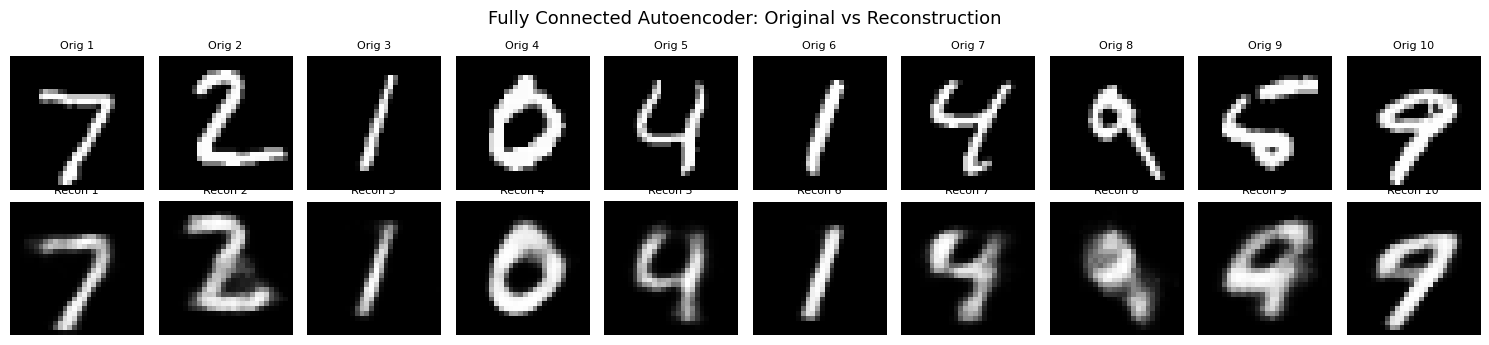

Saved EPS : /content/experiment7/plots/plot1_fc_original_vs_reconstruction.eps
Saved PNG : /content/experiment7/plots/plot1_fc_original_vs_reconstruction.png


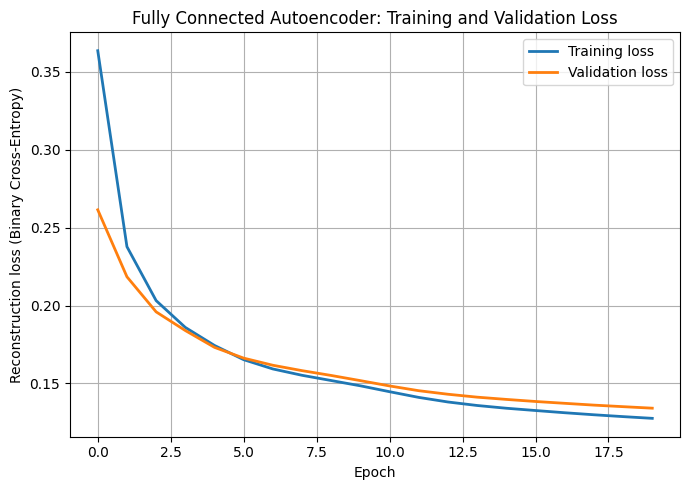

Saved EPS : /content/experiment7/plots/plot2_fc_training_validation_loss.eps
Saved PNG : /content/experiment7/plots/plot2_fc_training_validation_loss.png


In [13]:
# Plot 1: original vs reconstructed
fig, axes = plt.subplots(2, 10, figsize=(15, 3.5))
for i in range(10):
    axes[0, i].imshow(x_test[i, ..., 0], cmap="gray")
    axes[0, i].axis("off")
    axes[0, i].set_title(f"Orig {i+1}", fontsize=8)
    axes[1, i].imshow(fc_recon[i, ..., 0], cmap="gray")
    axes[1, i].axis("off")
    axes[1, i].set_title(f"Recon {i+1}", fontsize=8)
fig.suptitle("Fully Connected Autoencoder: Original vs Reconstruction", fontsize=13)
fig.tight_layout()
save_eps(PLOT_DIR / "plot1_fc_original_vs_reconstruction.eps")

# Plot 2: training/validation loss
plt.figure(figsize=(7, 5))
plt.plot(fc_history.history["loss"], label="Training loss", linewidth=2)
plt.plot(fc_history.history["val_loss"], label="Validation loss", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Reconstruction loss (Binary Cross-Entropy)")
plt.title("Fully Connected Autoencoder: Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
save_eps(PLOT_DIR / "plot2_fc_training_validation_loss.eps")

In [14]:
# =========================
# 5. CONVOLUTIONAL AUTOENCODER
# =========================
def build_cae():
    inp = keras.Input(shape=(28, 28, 1), name="image")
    x = layers.Conv2D(32, 3, activation="relu", padding="same")(inp)
    x = layers.MaxPooling2D(2, padding="same")(x)
    x = layers.Conv2D(64, 3, activation="relu", padding="same")(x)
    x = layers.MaxPooling2D(2, padding="same")(x)
    x = layers.Conv2D(64, 3, activation="relu", padding="same", name="latent_feature_map")(x)
    latent = x
    x = layers.UpSampling2D(2)(x)
    x = layers.Conv2D(32, 3, activation="relu", padding="same")(x)
    x = layers.UpSampling2D(2)(x)
    out = layers.Conv2D(1, 3, activation="sigmoid", padding="same")(x)
    cae = keras.Model(inp, out, name="convolutional_autoencoder")
    encoder = keras.Model(inp, latent, name="conv_encoder")
    return cae, encoder

start = time.perf_counter()
cae, cae_encoder = build_cae()
cae.compile(optimizer=keras.optimizers.Adam(1e-3), loss="binary_crossentropy")
cae_history = cae.fit(
    x_train_main, x_train_main,
    validation_data=(x_val, x_val),
    epochs=EPOCHS_CAE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    verbose=1,
)
cae_time = elapsed_minutes(start)
cae_recon = cae.predict(x_test, batch_size=BATCH_SIZE, verbose=0)
cae_metrics = image_metrics(x_test, cae_recon)
cae_params = count_params(cae)
cae.save(MODEL_DIR / "convolutional_autoencoder.keras")

print("CAE metrics:", cae_metrics)

Epoch 1/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 10s 64ms/step - loss: 0.2244 - val_loss: 0.1059
Epoch 2/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0931 - val_loss: 0.0888
Epoch 3/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0837 - val_loss: 0.0835
Epoch 4/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0791 - val_loss: 0.0802
Epoch 5/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0767 - val_loss: 0.0770
Epoch 6/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0748 - val_loss: 0.0757
Epoch 7/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0737 - val_loss: 0.0751
Epoch 8/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0728 - val_loss: 0.0741
Epoch 9/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0719 - val_loss: 0.0732
Epoch 10/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0714 - val_loss: 0.0727
Epoch 11/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0709 - val_loss: 0.0721
Epoch 12/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0704 - val_

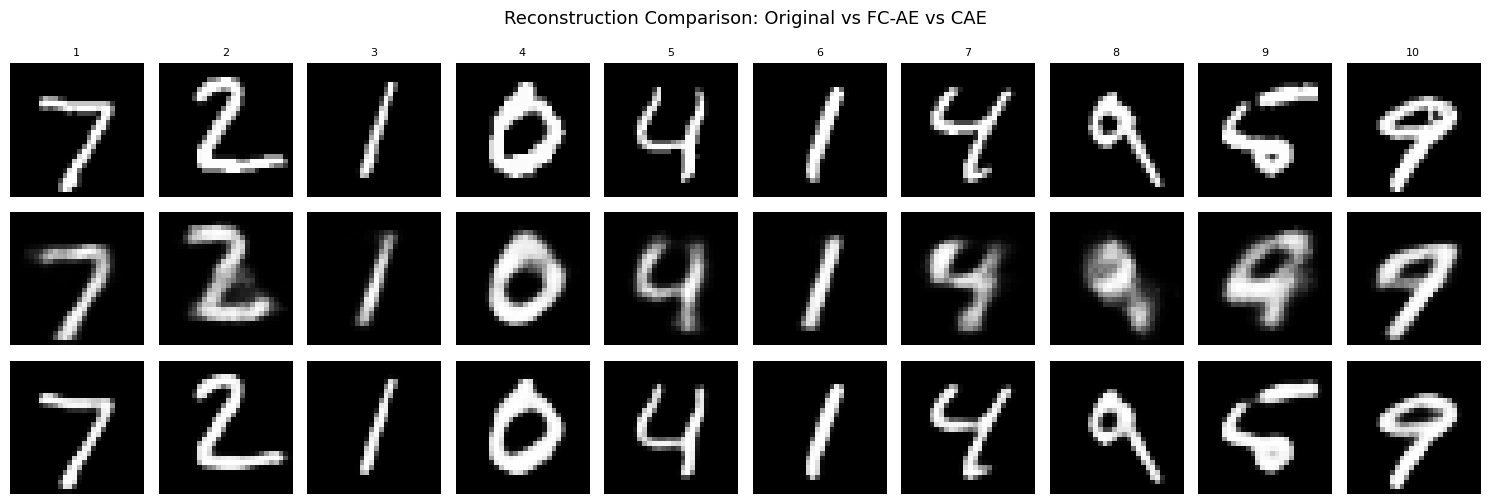

Saved EPS : /content/experiment7/plots/plot3_fc_vs_conv_reconstruction.eps
Saved PNG : /content/experiment7/plots/plot3_fc_vs_conv_reconstruction.png


In [15]:
# Plot 3: original -> FC -> CAE
fig, axes = plt.subplots(3, 10, figsize=(15, 5.2))
for i in range(10):
    axes[0, i].imshow(x_test[i, ..., 0], cmap="gray")
    axes[1, i].imshow(fc_recon[i, ..., 0], cmap="gray")
    axes[2, i].imshow(cae_recon[i, ..., 0], cmap="gray")
    for r in range(3):
        axes[r, i].axis("off")
    axes[0, i].set_title(f"{i+1}", fontsize=8)
axes[0, 0].set_ylabel("Original", fontsize=9)
axes[1, 0].set_ylabel("FC-AE", fontsize=9)
axes[2, 0].set_ylabel("CAE", fontsize=9)
fig.suptitle("Reconstruction Comparison: Original vs FC-AE vs CAE", fontsize=13)
fig.tight_layout()
save_eps(PLOT_DIR / "plot3_fc_vs_conv_reconstruction.eps")

In [16]:
# =========================
# 6. NOISE FUNCTIONS + DENOISING CAE
# =========================
def add_gaussian_noise(x, sigma, rng=None):
    if rng is None:
        rng = np.random.default_rng(SEED)
    noisy = x + rng.normal(0.0, sigma, size=x.shape).astype(np.float32)
    return np.clip(noisy, 0.0, 1.0).astype(np.float32)


def add_salt_pepper_noise(x, p, rng=None):
    if rng is None:
        rng = np.random.default_rng(SEED)
    noisy = x.copy().astype(np.float32)
    mask = rng.random(size=x.shape)
    noisy[mask < (p / 2.0)] = 0.0
    noisy[(mask >= (p / 2.0)) & (mask < p)] = 1.0
    return noisy

# Train the denoising model on a controlled mixed corruption set:
# Gaussian sigma=0.2 plus salt-and-pepper p=0.10.
rng_train = np.random.default_rng(SEED)
train_half = len(x_train_main) // 2
noisy_train = np.empty_like(x_train_main)
noisy_train[:train_half] = add_gaussian_noise(x_train_main[:train_half], 0.2, rng_train)
noisy_train[train_half:] = add_salt_pepper_noise(x_train_main[train_half:], 0.10, rng_train)

noisy_val = add_gaussian_noise(x_val, 0.2, np.random.default_rng(SEED + 1))

start = time.perf_counter()
dae, dae_encoder = build_cae()
dae.compile(optimizer=keras.optimizers.Adam(1e-3), loss="binary_crossentropy")
dae_history = dae.fit(
    noisy_train, x_train_main,
    validation_data=(noisy_val, x_val),
    epochs=EPOCHS_DAE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    verbose=1,
)
dae_time = elapsed_minutes(start)
dae.save(MODEL_DIR / "denoising_cae.keras")

Epoch 1/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 7s 40ms/step - loss: 0.2699 - val_loss: 0.1341
Epoch 2/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1150 - val_loss: 0.1020
Epoch 3/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0971 - val_loss: 0.0937
Epoch 4/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0916 - val_loss: 0.0895
Epoch 5/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0882 - val_loss: 0.0870
Epoch 6/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0862 - val_loss: 0.0852
Epoch 7/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0846 - val_loss: 0.0839
Epoch 8/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0834 - val_loss: 0.0828
Epoch 9/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0824 - val_loss: 0.0819
Epoch 10/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0816 - val_loss: 0.0812
Epoch 11/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0808 - val_loss: 0.0806
Epoch 12/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0802 - val_l

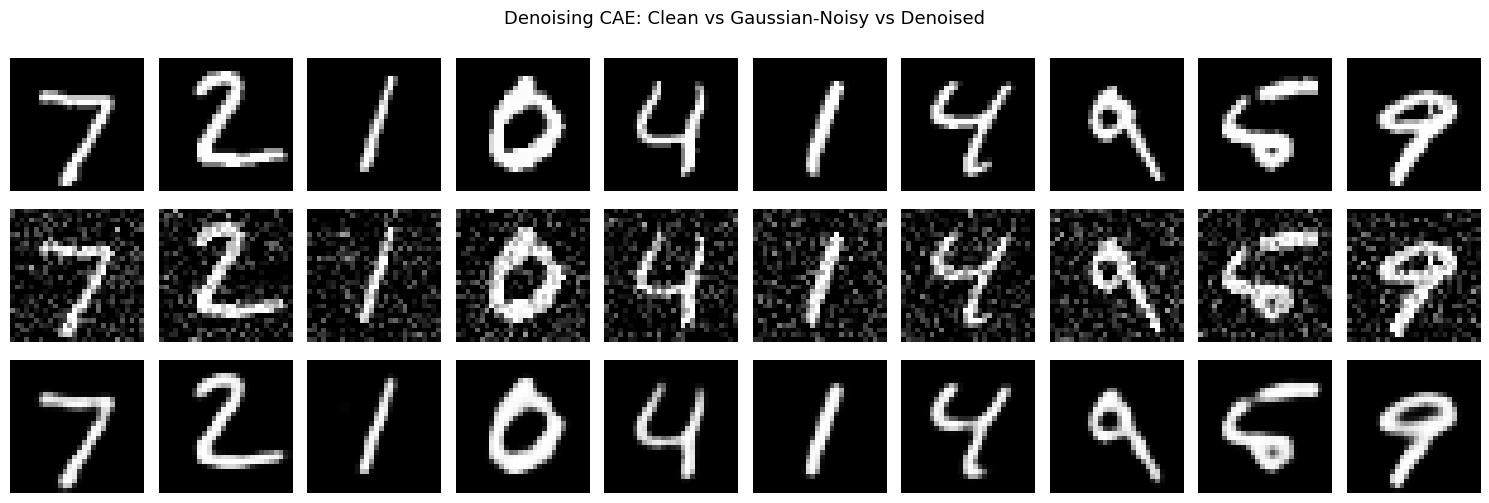

Saved EPS : /content/experiment7/plots/plot4_clean_noisy_denoised.eps
Saved PNG : /content/experiment7/plots/plot4_clean_noisy_denoised.png


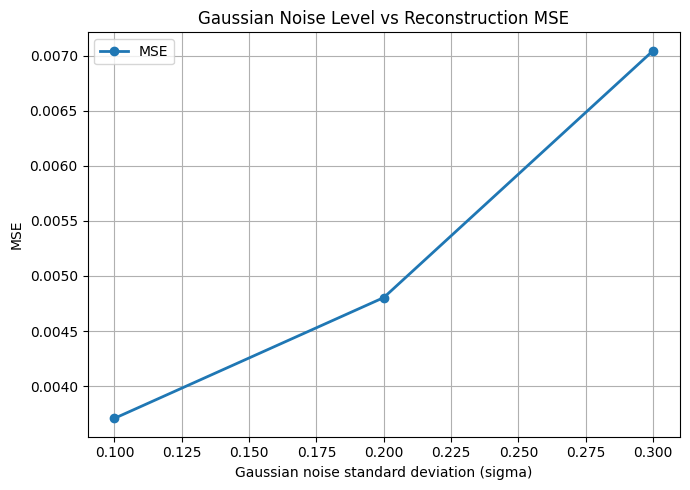

Saved EPS : /content/experiment7/plots/plot5a_gaussian_noise_vs_mse.eps
Saved PNG : /content/experiment7/plots/plot5a_gaussian_noise_vs_mse.png


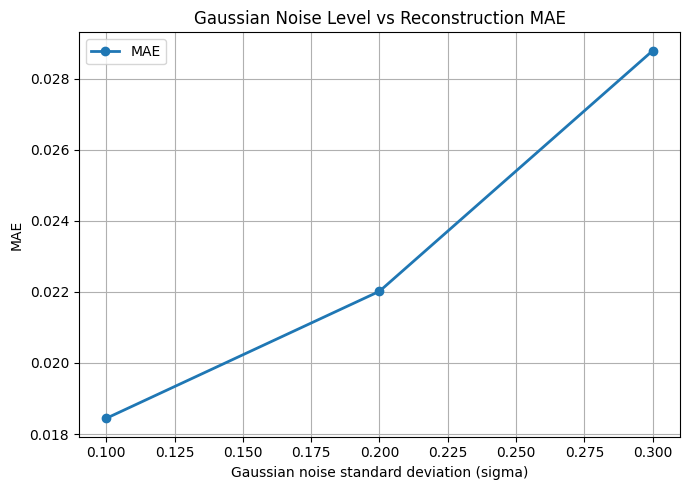

Saved EPS : /content/experiment7/plots/plot5b_gaussian_noise_vs_mae.eps
Saved PNG : /content/experiment7/plots/plot5b_gaussian_noise_vs_mae.png


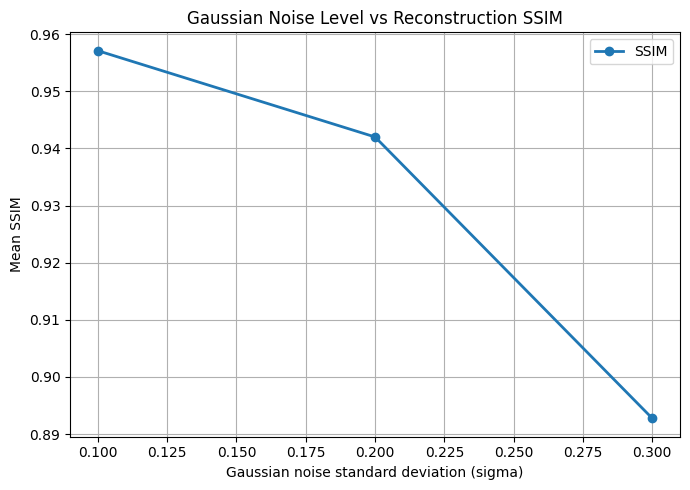

Saved EPS : /content/experiment7/plots/plot5c_gaussian_noise_vs_ssim.eps
Saved PNG : /content/experiment7/plots/plot5c_gaussian_noise_vs_ssim.png


In [17]:
# Plot 4: clean/noisy/denoised using Gaussian sigma=0.2
plot4_noisy = add_gaussian_noise(x_test[:10], 0.2, np.random.default_rng(SEED + 2))
plot4_denoised = dae.predict(plot4_noisy, batch_size=BATCH_SIZE, verbose=0)
fig, axes = plt.subplots(3, 10, figsize=(15, 5.2))
for i in range(10):
    axes[0, i].imshow(x_test[i, ..., 0], cmap="gray")
    axes[1, i].imshow(plot4_noisy[i, ..., 0], cmap="gray")
    axes[2, i].imshow(plot4_denoised[i, ..., 0], cmap="gray")
    for r in range(3):
        axes[r, i].axis("off")
axes[0, 0].set_ylabel("Clean", fontsize=9)
axes[1, 0].set_ylabel("Noisy", fontsize=9)
axes[2, 0].set_ylabel("Denoised", fontsize=9)
fig.suptitle("Denoising CAE: Clean vs Gaussian-Noisy vs Denoised", fontsize=13)
fig.tight_layout()
save_eps(PLOT_DIR / "plot4_clean_noisy_denoised.eps")

# Plot 5: Gaussian noise level vs MSE / MAE / SSIM.
gaussian_levels = [0.1, 0.2, 0.3]
gaussian_results = []
for sigma in gaussian_levels:
    noisy = add_gaussian_noise(x_test, sigma, np.random.default_rng(SEED + int(sigma * 100)))
    den = dae.predict(noisy, batch_size=BATCH_SIZE, verbose=0)
    m = image_metrics(x_test, den)
    gaussian_results.append({"noise_level": sigma, **m})

g_noise_df = pd.DataFrame(gaussian_results)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(g_noise_df["noise_level"], g_noise_df["mse"], marker="o", label="MSE", linewidth=2)
ax.set_xlabel("Gaussian noise standard deviation (sigma)")
ax.set_ylabel("MSE")
ax.set_title("Gaussian Noise Level vs Reconstruction MSE")
ax.grid(True)
ax.legend()
fig.tight_layout()
save_eps(PLOT_DIR / "plot5a_gaussian_noise_vs_mse.eps")

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(g_noise_df["noise_level"], g_noise_df["mae"], marker="o", label="MAE", linewidth=2)
ax.set_xlabel("Gaussian noise standard deviation (sigma)")
ax.set_ylabel("MAE")
ax.set_title("Gaussian Noise Level vs Reconstruction MAE")
ax.grid(True)
ax.legend()
fig.tight_layout()
save_eps(PLOT_DIR / "plot5b_gaussian_noise_vs_mae.eps")

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(g_noise_df["noise_level"], g_noise_df["ssim"], marker="o", label="SSIM", linewidth=2)
ax.set_xlabel("Gaussian noise standard deviation (sigma)")
ax.set_ylabel("Mean SSIM")
ax.set_title("Gaussian Noise Level vs Reconstruction SSIM")
ax.grid(True)
ax.legend()
fig.tight_layout()
save_eps(PLOT_DIR / "plot5c_gaussian_noise_vs_ssim.eps")

# Additional required corruption type: salt-and-pepper evaluation.
sp_levels = [0.05, 0.10, 0.20]
sp_results = []
for p in sp_levels:
    noisy = add_salt_pepper_noise(x_test, p, np.random.default_rng(SEED + int(p * 1000)))
    den = dae.predict(noisy, batch_size=BATCH_SIZE, verbose=0)
    m = image_metrics(x_test, den)
    sp_results.append({"noise_level": p, **m})
sp_df = pd.DataFrame(sp_results)

In [21]:
# =========================
# 7. VAE
# =========================
class VAE(keras.Model):
    def __init__(self, latent_dim=2, **kwargs):
        super().__init__(**kwargs)
        self.latent_dim = latent_dim
        self.encoder_conv1 = layers.Conv2D(32, 3, strides=2, padding="same", activation="relu")
        self.encoder_conv2 = layers.Conv2D(64, 3, strides=2, padding="same", activation="relu")
        self.encoder_flat = layers.Flatten()
        self.encoder_dense = layers.Dense(128, activation="relu")
        self.z_mean_layer = layers.Dense(latent_dim, name="z_mean")
        self.z_log_var_layer = layers.Dense(latent_dim, name="z_log_var")

        self.decoder_dense = layers.Dense(7 * 7 * 64, activation="relu")
        self.decoder_reshape = layers.Reshape((7, 7, 64))
        self.decoder_deconv1 = layers.Conv2DTranspose(64, 3, strides=2, padding="same", activation="relu")
        self.decoder_deconv2 = layers.Conv2DTranspose(32, 3, strides=2, padding="same", activation="relu")
        self.decoder_out = layers.Conv2DTranspose(1, 3, padding="same", activation="sigmoid")

        self.total_loss_tracker = keras.metrics.Mean(name="loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [self.total_loss_tracker, self.reconstruction_loss_tracker, self.kl_loss_tracker]

    def encode(self, x, training=False):
        x = self.encoder_conv1(x, training=training)
        x = self.encoder_conv2(x, training=training)
        x = self.encoder_flat(x)
        x = self.encoder_dense(x)
        return self.z_mean_layer(x), self.z_log_var_layer(x)

    def reparameterize(self, z_mean, z_log_var):
        eps = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_log_var) * eps

    def decode(self, z, training=False):
        x = self.decoder_dense(z, training=training)
        x = self.decoder_reshape(x)
        x = self.decoder_deconv1(x, training=training)
        x = self.decoder_deconv2(x, training=training)
        return self.decoder_out(x, training=training)

    def call(self, inputs, training=False):
        z_mean, z_log_var = self.encode(inputs, training=training)
        z = self.reparameterize(z_mean, z_log_var)
        reconstruction = self.decode(z, training=training)
        return reconstruction

    def compute_losses(self, data, training):
        z_mean, z_log_var = self.encode(data, training=training)
        z = self.reparameterize(z_mean, z_log_var)
        reconstruction = self.decode(z, training=training)
        bce = keras.backend.binary_crossentropy(data, reconstruction)
        reconstruction_loss = tf.reduce_mean(tf.reduce_sum(bce, axis=(1, 2)))
        kl_loss = -0.5 * tf.reduce_mean(
            tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1)
        )
        total_loss = reconstruction_loss + kl_loss
        return total_loss, reconstruction_loss, kl_loss

    def train_step(self, data):
        if isinstance(data, tuple):
            data = data[0]
        with tf.GradientTape() as tape:
            total_loss, reconstruction_loss, kl_loss = self.compute_losses(data, training=True)
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {m.name: m.result() for m in self.metrics}

    def test_step(self, data):
        if isinstance(data, tuple):
            data = data[0]
        total_loss, reconstruction_loss, kl_loss = self.compute_losses(data, training=False)
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {m.name: m.result() for m in self.metrics}

start = time.perf_counter()
vae = VAE(VAE_LATENT_DIM, name="mnist_vae")
vae.compile(optimizer=keras.optimizers.Adam(1e-3))
vae_history = vae.fit(
    x_train_main,
    validation_data=(x_val,),
    epochs=EPOCHS_VAE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    verbose=1,
)
vae_time = elapsed_minutes(start)
_ = vae(x_train[:1], training=False)
vae.save_weights(MODEL_DIR / "vae.weights.h5")

# Deterministic VAE reconstruction using the posterior mean.
z_mean_test, z_log_var_test = vae.encode(x_test, training=False)
z_mean_test = z_mean_test.numpy()
z_log_var_test = z_log_var_test.numpy()
vae_recon = vae.decode(z_mean_test, training=False).numpy()
vae_metrics = image_metrics(x_test, vae_recon)
vae_errors = per_image_mse(x_test, vae_recon)

# Evaluate final VAE losses on test set with a fresh forward pass.
vae_test_total, vae_test_recon_loss, vae_test_kl = vae.compute_losses(tf.convert_to_tensor(x_test), training=False)
vae_loss_values = {
    "reconstruction_loss": float(vae_test_recon_loss.numpy()),
    "kl_loss": float(vae_test_kl.numpy()),
    "total_loss": float(vae_test_total.numpy()),
}
vae_params = count_params(vae)


Epoch 1/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 14s 63ms/step - kl_loss: 3.8329 - loss: 297.0518 - reconstruction_loss: 293.2189 - val_kl_loss: 3.6642 - val_loss: 209.8144 - val_reconstruction_loss: 206.1502
Epoch 2/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - kl_loss: 3.2899 - loss: 200.6830 - reconstruction_loss: 197.3931 - val_kl_loss: 3.2256 - val_loss: 197.2172 - val_reconstruction_loss: 193.9916
Epoch 3/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - kl_loss: 2.9284 - loss: 194.4520 - reconstruction_loss: 191.5235 - val_kl_loss: 2.7203 - val_loss: 194.3144 - val_reconstruction_loss: 191.5941
Epoch 4/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - kl_loss: 3.6373 - loss: 187.4885 - reconstruction_loss: 183.8512 - val_kl_loss: 4.1550 - val_loss: 185.0303 - val_reconstruction_loss: 180.8753
Epoch 5/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - kl_loss: 4.2312 - loss: 181.8414 - reconstruction_loss: 177.6102 - val_kl_loss: 4.1997 - val_loss: 182.4118 - val_reconstruction_loss: 178.2121
Epoch 6/20
71/71 ━

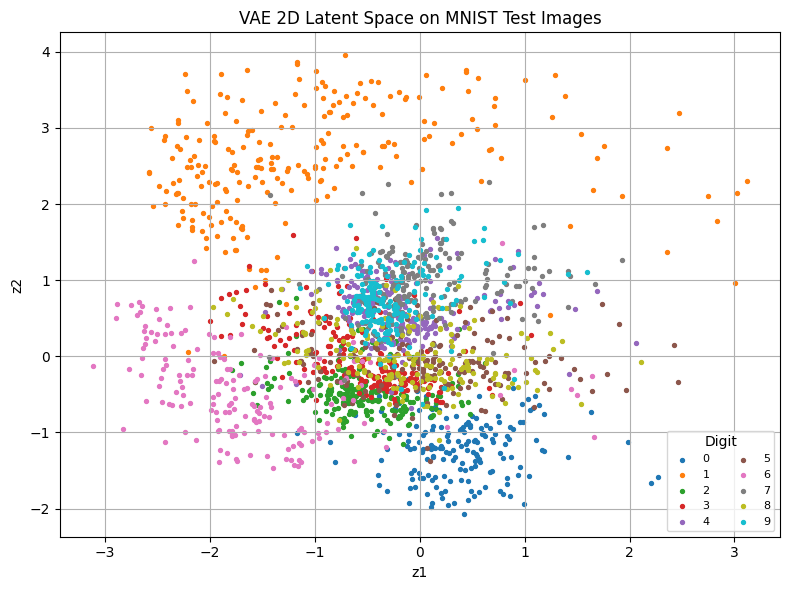

Saved EPS : /content/experiment7/plots/plot6_vae_latent_space.eps
Saved PNG : /content/experiment7/plots/plot6_vae_latent_space.png


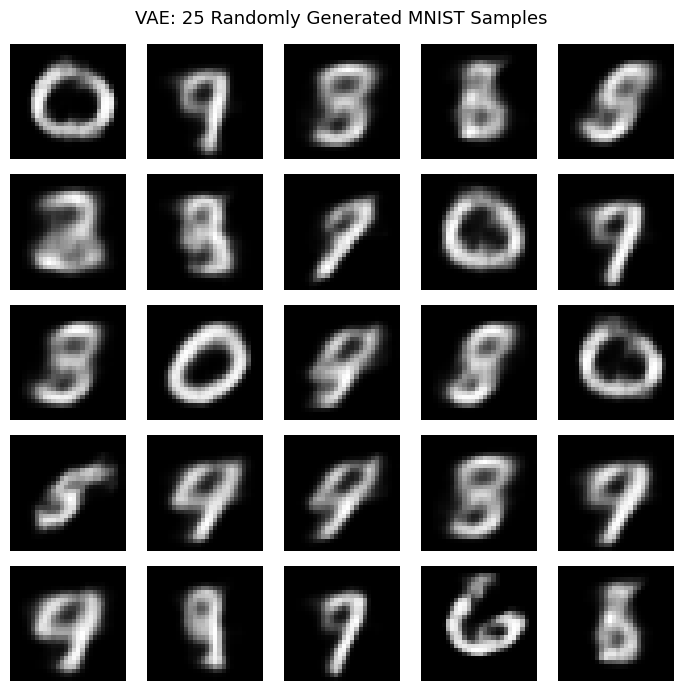

Saved EPS : /content/experiment7/plots/plot7_vae_generated_samples.eps
Saved PNG : /content/experiment7/plots/plot7_vae_generated_samples.png


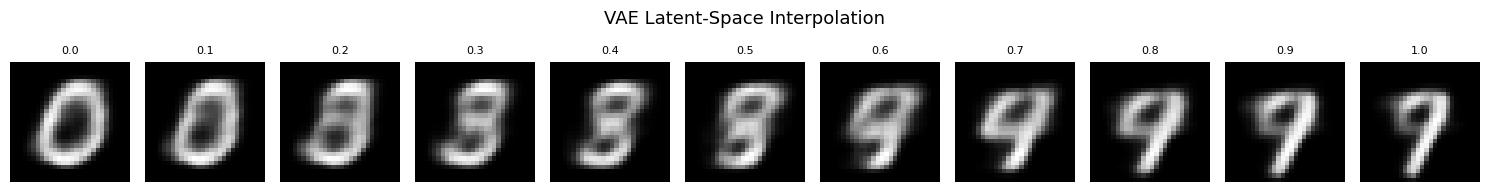

Saved EPS : /content/experiment7/plots/plot8_vae_latent_interpolation.eps
Saved PNG : /content/experiment7/plots/plot8_vae_latent_interpolation.png


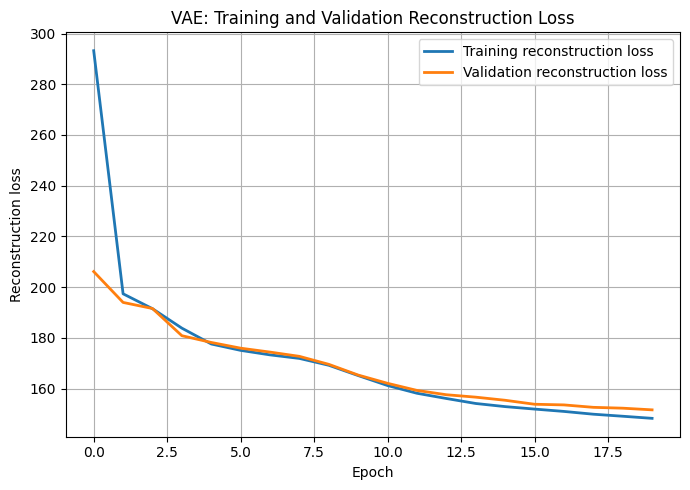

Saved EPS : /content/experiment7/plots/plot9_vae_training_validation_reconstruction_loss.eps
Saved PNG : /content/experiment7/plots/plot9_vae_training_validation_reconstruction_loss.png


In [22]:
# Plot 6: VAE latent space
plt.figure(figsize=(8, 6))
for digit in range(10):
    idx = y_test == digit
    plt.scatter(z_mean_test[idx, 0], z_mean_test[idx, 1], s=8, label=str(digit))
plt.xlabel("z1")
plt.ylabel("z2")
plt.title("VAE 2D Latent Space on MNIST Test Images")
plt.legend(title="Digit", ncol=2, fontsize=8)
plt.grid(True)
plt.tight_layout()
save_eps(PLOT_DIR / "plot6_vae_latent_space.eps")

# Plot 7: 25 randomly generated samples from N(0,I)
rng = np.random.default_rng(SEED + 100)
z_samples = rng.normal(size=(25, VAE_LATENT_DIM)).astype("float32")
generated = vae.decode(z_samples, training=False).numpy()
fig, axes = plt.subplots(5, 5, figsize=(7, 7))
for i, ax in enumerate(axes.flat):
    ax.imshow(generated[i, ..., 0], cmap="gray")
    ax.axis("off")
fig.suptitle("VAE: 25 Randomly Generated MNIST Samples", fontsize=13)
fig.tight_layout()
save_eps(PLOT_DIR / "plot7_vae_generated_samples.eps")

# Plot 8: latent interpolation
z_a = z_mean_test[np.where(y_test == 0)[0][0]]
z_b = z_mean_test[np.where(y_test == 7)[0][0]]
alphas = np.linspace(0, 1, 11, dtype=np.float32)
z_interp = np.array([(1-a) * z_a + a * z_b for a in alphas], dtype=np.float32)
interp_images = vae.decode(z_interp, training=False).numpy()
fig, axes = plt.subplots(1, 11, figsize=(15, 2))
for i, ax in enumerate(axes):
    ax.imshow(interp_images[i, ..., 0], cmap="gray")
    ax.set_title(f"{alphas[i]:.1f}", fontsize=8)
    ax.axis("off")
fig.suptitle("VAE Latent-Space Interpolation", fontsize=13)
fig.tight_layout()
save_eps(PLOT_DIR / "plot8_vae_latent_interpolation.eps")

# Plot 9: VAE training/validation reconstruction loss
plt.figure(figsize=(7, 5))
plt.plot(vae_history.history["reconstruction_loss"], label="Training reconstruction loss", linewidth=2)
plt.plot(vae_history.history["val_reconstruction_loss"], label="Validation reconstruction loss", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("Reconstruction loss")
plt.title("VAE: Training and Validation Reconstruction Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
save_eps(PLOT_DIR / "plot9_vae_training_validation_reconstruction_loss.eps")

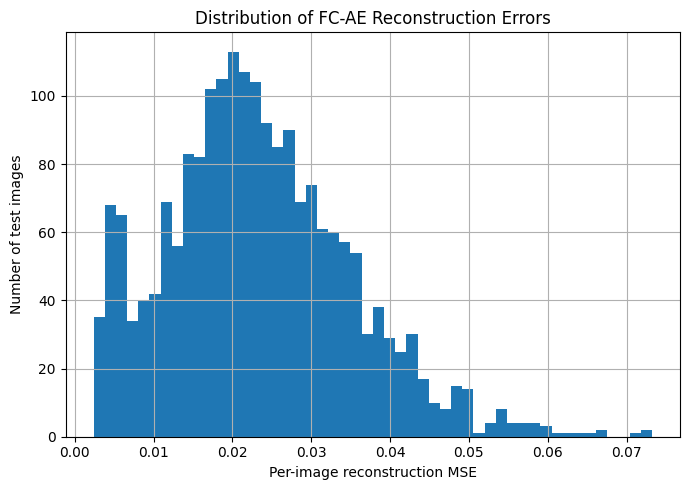

Saved EPS : /content/experiment7/plots/plot_error_distribution.eps
Saved PNG : /content/experiment7/plots/plot_error_distribution.png


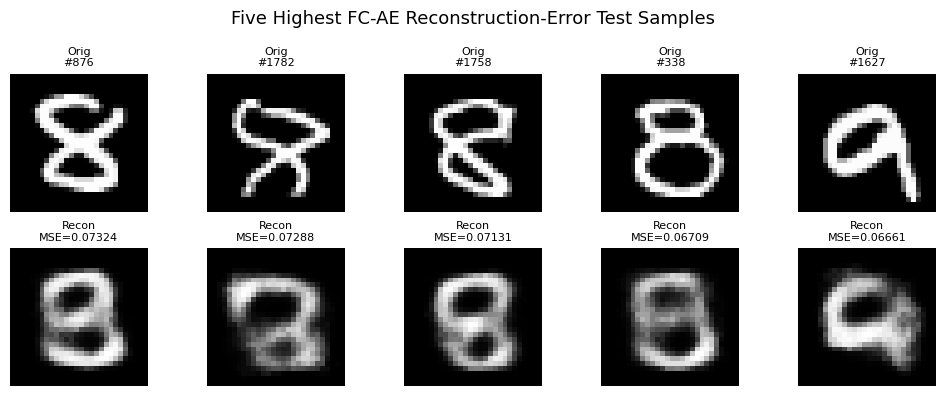

Saved EPS : /content/experiment7/plots/high_error_five_samples.eps
Saved PNG : /content/experiment7/plots/high_error_five_samples.png


In [23]:
plt.figure(figsize=(7, 5))
plt.hist(fc_errors, bins=50)
plt.xlabel("Per-image reconstruction MSE")
plt.ylabel("Number of test images")
plt.title("Distribution of FC-AE Reconstruction Errors")
plt.grid(True)
plt.tight_layout()
save_eps(PLOT_DIR / "plot_error_distribution.eps")

high_idx = np.argsort(fc_errors)[-5:][::-1]
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for col, idx in enumerate(high_idx):
    axes[0, col].imshow(x_test[idx, ..., 0], cmap="gray")
    axes[0, col].axis("off")
    axes[0, col].set_title(f"Orig\n#{idx}", fontsize=8)
    axes[1, col].imshow(fc_recon[idx, ..., 0], cmap="gray")
    axes[1, col].axis("off")
    axes[1, col].set_title(f"Recon\nMSE={fc_errors[idx]:.5f}", fontsize=8)
fig.suptitle("Five Highest FC-AE Reconstruction-Error Test Samples", fontsize=13)
fig.tight_layout()
save_eps(PLOT_DIR / "high_error_five_samples.eps")



Training FC-AE with latent dimension 2
Epoch 1/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - loss: 0.3625 - val_loss: 0.2702
Epoch 2/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2638 - val_loss: 0.2618
Epoch 3/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2506 - val_loss: 0.2444
Epoch 4/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2354 - val_loss: 0.2342
Epoch 5/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2281 - val_loss: 0.2294
Epoch 6/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2237 - val_loss: 0.2262
Epoch 7/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2209 - val_loss: 0.2242
Epoch 8/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2189 - val_loss: 0.2225
Epoch 9/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2172 - val_loss: 0.2210
Epoch 10/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2158 - val_loss: 0.2195
Epoch 11/20
71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2146 - val_loss: 0.2183
Epoch 12/20
71/71 ━━━━━━━━━━━━━━━

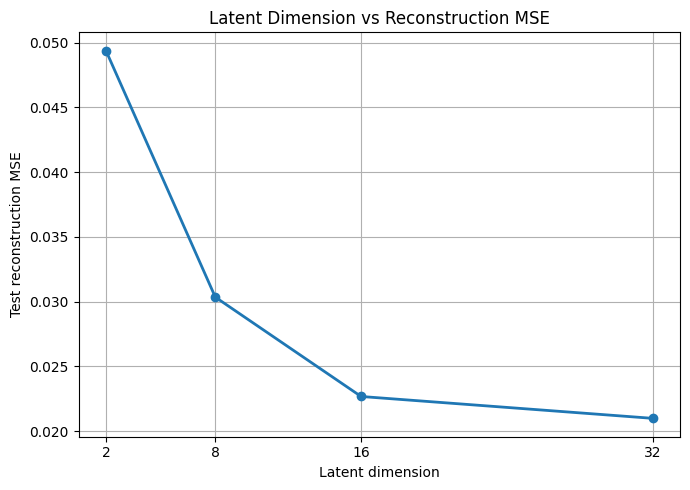

Saved EPS : /content/experiment7/plots/plot10_latent_dimension_vs_mse.eps
Saved PNG : /content/experiment7/plots/plot10_latent_dimension_vs_mse.png


In [24]:
# =========================
# 9. LATENT DIMENSION STUDY
# =========================
latent_dims = [2, 8, 16, 32]
latent_results = []
latent_models = {}
for dz in latent_dims:
    print(f"\nTraining FC-AE with latent dimension {dz}")
    start = time.perf_counter()
    model, encoder = build_fc_autoencoder(dz)
    model.compile(optimizer=keras.optimizers.Adam(1e-3), loss="binary_crossentropy")
    hist = model.fit(
        x_train_main, x_train_main,
        validation_data=(x_val, x_val),
        epochs=EPOCHS_AE,
        batch_size=BATCH_SIZE,
        shuffle=True,
        verbose=1,
    )
    t = elapsed_minutes(start)
    pred = model.predict(x_test, batch_size=BATCH_SIZE, verbose=0)
    met = image_metrics(x_test, pred)
    latent_results.append({
        "latent_dimension": dz,
        "mse": met["mse"],
        "ssim": met["ssim"],
        "parameters": count_params(model),
        "time_minutes": t,
    })
    latent_models[dz] = model

latent_df = pd.DataFrame(latent_results)

plt.figure(figsize=(7, 5))
plt.plot(latent_df["latent_dimension"], latent_df["mse"], marker="o", linewidth=2)
plt.xlabel("Latent dimension")
plt.ylabel("Test reconstruction MSE")
plt.title("Latent Dimension vs Reconstruction MSE")
plt.xticks(latent_dims)
plt.grid(True)
plt.tight_layout()
save_eps(PLOT_DIR / "plot10_latent_dimension_vs_mse.eps")

In [25]:
# =========================
# 10. MODEL COMPARISON TABLES
# =========================
# Denoising model is evaluated on Gaussian sigma=0.2 for the consolidated table.
dae_eval_noisy = add_gaussian_noise(x_test, 0.2, np.random.default_rng(SEED + 3))
dae_recon = dae.predict(dae_eval_noisy, batch_size=BATCH_SIZE, verbose=0)
dae_metrics = image_metrics(x_test, dae_recon)
dae_params = count_params(dae)

comparison_rows = [
    {"model":"FC Autoencoder", "mse":fc_metrics["mse"], "mae":fc_metrics["mae"], "ssim":fc_metrics["ssim"], "parameters":fc_params, "time_minutes":fc_time},
    {"model":"Convolutional Autoencoder", "mse":cae_metrics["mse"], "mae":cae_metrics["mae"], "ssim":cae_metrics["ssim"], "parameters":cae_params, "time_minutes":cae_time},
    {"model":"Denoising CAE (Gaussian sigma=0.2)", "mse":dae_metrics["mse"], "mae":dae_metrics["mae"], "ssim":dae_metrics["ssim"], "parameters":dae_params, "time_minutes":dae_time},
    {"model":"VAE (z=2)", "mse":vae_metrics["mse"], "mae":vae_metrics["mae"], "ssim":vae_metrics["ssim"], "parameters":vae_params, "time_minutes":vae_time},
]
comparison_df = pd.DataFrame(comparison_rows)

In [27]:
print(comparison_df.to_markdown(index=False))

| model                              |        mse |       mae |     ssim |   parameters |   time_minutes |
|:-----------------------------------|-----------:|----------:|---------:|-------------:|---------------:|
| FC Autoencoder                     | 0.0232932  | 0.0607156 | 0.72281  |       211040 |       0.195145 |
| Convolutional Autoencoder          | 0.00254394 | 0.0149632 | 0.974337 |        74497 |       0.407594 |
| Denoising CAE (Gaussian sigma=0.2) | 0.00482378 | 0.0220702 | 0.942046 |        74497 |       0.328673 |
| VAE (z=2)                          | 0.0444094  | 0.103936  | 0.485281 |       485957 |       0.432425 |


In [28]:
# =========================
# 11. SAVE NUMERICAL RESULTS
# =========================
results = {
    "configuration": {
        "seed": SEED,
        "train_images": N_TRAIN,
        "test_images": N_TEST,
        "validation_images": VAL_COUNT,
        "batch_size": BATCH_SIZE,
        "epochs_fc": EPOCHS_AE,
        "epochs_cae": EPOCHS_CAE,
        "epochs_dae": EPOCHS_DAE,
        "epochs_vae": EPOCHS_VAE,
        "fc_latent_dim": LATENT_DIM,
        "vae_latent_dim": VAE_LATENT_DIM,
    },
    "fc": {**fc_metrics, "parameters":fc_params, "time_minutes":fc_time},
    "cae": {**cae_metrics, "parameters":cae_params, "time_minutes":cae_time},
    "dae": {**dae_metrics, "parameters":dae_params, "time_minutes":dae_time},
    "vae": {**vae_metrics, **vae_loss_values, "parameters":vae_params, "time_minutes":vae_time},
    "gaussian_noise": gaussian_results,
    "salt_pepper_noise": sp_results,
    "latent_dimension": latent_results,
    "high_error_indices": [int(i) for i in high_idx],
    "high_error_values": [float(fc_errors[i]) for i in high_idx],
}
with open(RESULT_DIR / "results.json", "w") as f:
    json.dump(results, f, indent=2)

comparison_df.to_csv(RESULT_DIR / "model_comparison.csv", index=False)
g_noise_df.to_csv(RESULT_DIR / "gaussian_noise_results.csv", index=False)
sp_df.to_csv(RESULT_DIR / "salt_pepper_results.csv", index=False)
latent_df.to_csv(RESULT_DIR / "latent_dimension_results.csv", index=False)

In [30]:
import shutil
from google.colab import files

# Zip the plots folder
shutil.make_archive(
    "/content/Experiment_7_Plots",
    "zip",
    "/content/experiment7/plots"
)

# Download
files.download("/content/Experiment_7_Plots.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [31]:
import shutil
from google.colab import files

# Zip the results folder
shutil.make_archive(
    "/content/Experiment_7_Results",
    "zip",
    "/content/experiment7/results"
)

# Download the ZIP
files.download("/content/Experiment_7_Results.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>